<a href="https://colab.research.google.com/github/DivyaS09122006/FireNetCNN_XAI/blob/main/FireNet_CNN_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi
import tensorflow as tf
print(tf.__version__, tf.config.list_physical_devices('GPU'))

/bin/bash: line 1: nvidia-smi: command not found
2.20.0 []


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Screenshot_20240114-130416_WPS Office.jpg', 'CS105 Course Syllabus IIIT Dharwad.pdf', 'Colab Notebooks', 'Classroom', '2. UNIT-I.gdoc', 'Share STATISTICS SWETHA.pptx', 'Introduction to DS and AI_ Assignment - Sheet1.gdoc', 'Resume', 'Screenshot_20241007-171826_PhonePe.jpg', '3. UNIT-II (1).gdoc', '3. UNIT-II.gdoc', 'STATISTICS.gslides', 'Document from Swetha Subbu 🥰', 'cyber security ', 'prob tutorial.pdf', 'Share STATISTICS SWETHA.gslides', 'DocScanner Dec 10, 2024 9-32 PM.pdf', 'Screenshot_20241224-123823_WPS Office.jpg', 'IDEA PITCH.pptx', 'Untitled document (25).gdoc', 'Untitled form.gform', 'Research data iet.gdoc', 'CBA_Course Intro.gslides', 'IET 1.gdoc', 'dataset.gsheet', 'course list for Aug_Nov25.pdf', 'art.pdf', 'Step-In.pdf', 'CYBER SECURITY.gdoc', 'Cybersecurity-in-Military-and-Intelligence1[1].gslides', 'Even CSE.csv', 'ESI Budget Report.gdoc', '24bcs150 (3).pdf', 'Untitled spreadsheet (3).gsheet', 'Even CSE.gsheet', '24bcs150 (2).pdf', 'Untitled document (24).gdoc', 'I

In [5]:
ROOT = '/content/drive/MyDrive/processed'   # copy the name exactly as printed
print(os.path.exists(ROOT))    # must print True

True


In [6]:
import os, glob, time, random
import numpy as np, cv2, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, jaccard_score, matthews_corrcoef, roc_auc_score, confusion_matrix, roc_curve)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [7]:
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for dp, dn, fn in os.walk(ROOT):
    imgs  = [f for f in fn if f.lower().endswith(IMG_EXT)]
    other = [f for f in fn if not f.lower().endswith(IMG_EXT)]
    depth = dp.replace(ROOT, '').count('/')
    print('  ' * depth + f"{os.path.basename(dp) or 'ROOT'}/   images: {len(imgs)}",
          f"   other: {other[:4]}" if other else "")

processed/   images: 0    other: ['metadata.csv']
  train/   images: 0 
    nofire/   images: 800 
    smokefire/   images: 800 
    smoke/   images: 800 
    fire/   images: 800 
  val/   images: 0 
    smokefire/   images: 200 
    smoke/   images: 200 
    nofire/   images: 200 
    fire/   images: 200 
  test/   images: 0 
    smokefire/   images: 200 
    fire/   images: 200 
    nofire/   images: 200 
    smoke/   images: 200 


In [8]:
def show_samples(folder, n=5):
    paths = glob.glob(f'{folder}/*')[:n]
    plt.figure(figsize=(15,3))
    for i, p in enumerate(paths):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1); plt.imshow(img); plt.title(img.shape); plt.axis('off')
    plt.show()

show_samples(f'{ROOT}/Dataset_A/fire')   # change to a folder from your tree

<Figure size 1500x300 with 0 Axes>

In [9]:
import pandas as pd, os

ROOT = '/content/drive/MyDrive/processed'      # no space, no doubling
print(os.path.exists(ROOT))                     # should print True
print(os.listdir(ROOT))                         # should show ['train','val','test','metadata.csv'] or similar

meta = pd.read_csv(f'{ROOT}/metadata.csv')
print(meta.shape)
print(meta.columns.tolist())
meta.head(10)

True
['metadata.csv', 'train', 'val', 'test', 'FireNET processed data']
(4800, 4)
['split', 'label', 'image_path', 'source']


,split,label,image_path,source
0,train,fire,processed\train\fire\fire_train_1001.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
1,train,fire,processed\train\fire\fire_train_1002.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
2,train,fire,processed\train\fire\fire_train_1003.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
3,train,fire,processed\train\fire\fire_train_1004.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
4,train,fire,processed\train\fire\fire_train_1005.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
5,train,fire,processed\train\fire\fire_train_1006.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
6,train,fire,processed\train\fire\fire_train_1007.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
7,train,fire,processed\train\fire\fire_train_1008.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
8,train,fire,processed\train\fire\fire_train_1009.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
9,train,fire,processed\train\fire\fire_train_1010.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...


In [10]:
import os
ROOT = '/content/drive/MyDrive/processed'
BASE = ROOT

print(os.path.exists(BASE))
print(os.listdir(BASE))                          # expect train, val, test, metadata.csv
print(os.listdir(f'{BASE}/train'))               # expect fire, smokefire, smoke, nofire
print(len(glob.glob(f'{BASE}/train/fire/*')))    # expect 800

True
['metadata.csv', 'train', 'val', 'test', 'FireNET processed data']
['nofire', 'smokefire', 'smoke', 'fire']
800


In [11]:
import glob, cv2, numpy as np

FIRE_CLASSES   = ['fire', 'smokefire']
NOFIRE_CLASSES = ['nofire', 'smoke']

X, y, paths = [], [], []
for split in ['train', 'val', 'test']:
    for cls in FIRE_CLASSES + NOFIRE_CLASSES:
        label = 1 if cls in FIRE_CLASSES else 0
        for p in glob.glob(f'{BASE}/{split}/{cls}/*'):
            img = cv2.imread(p)
            if img is None: continue
            img = cv2.cvtColor(cv2.resize(img, (150,150)), cv2.COLOR_BGR2RGB)
            X.append(img); y.append(label); paths.append(p)

assert len(X) > 0, "No images loaded - BASE path is wrong"
X = np.array(X, dtype='float32') / 255.0
y = np.array(y, dtype='int64')
print(X.shape, np.bincount(y))    # expect (4800, 150, 150, 3) and [2400 2400]

(4800, 150, 150, 3) [2400 2400]


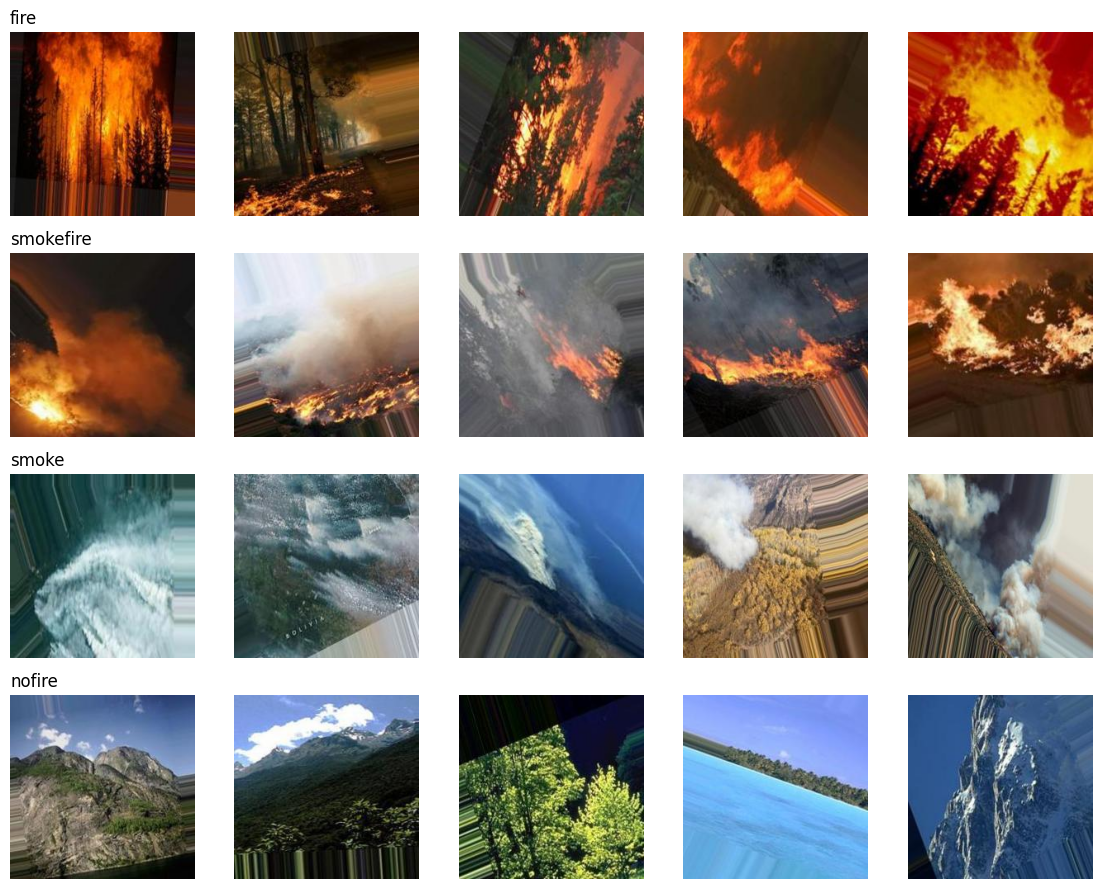

In [12]:
import matplotlib.pyplot as plt, random
fig, ax = plt.subplots(4, 5, figsize=(14,11))
for r, cls in enumerate(['fire','smokefire','smoke','nofire']):
    ps = random.sample(glob.glob(f'{BASE}/train/{cls}/*'), 5)
    for c, p in enumerate(ps):
        ax[r,c].imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); ax[r,c].axis('off')
    ax[r,0].set_title(cls, loc='left')
plt.show()

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)

In [14]:
train_aug = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True, fill_mode='nearest'
)
# brightness is skipped here; add it later with a tf.image.random_brightness step if you want it

In [15]:
def make_train_flow(X_tr, y_tr, batch_size=32):
    return train_aug.flow(X_tr, y_tr, batch_size=batch_size, shuffle=True, seed=SEED)
# Validation: use X_val, y_val directly, with no augmentation

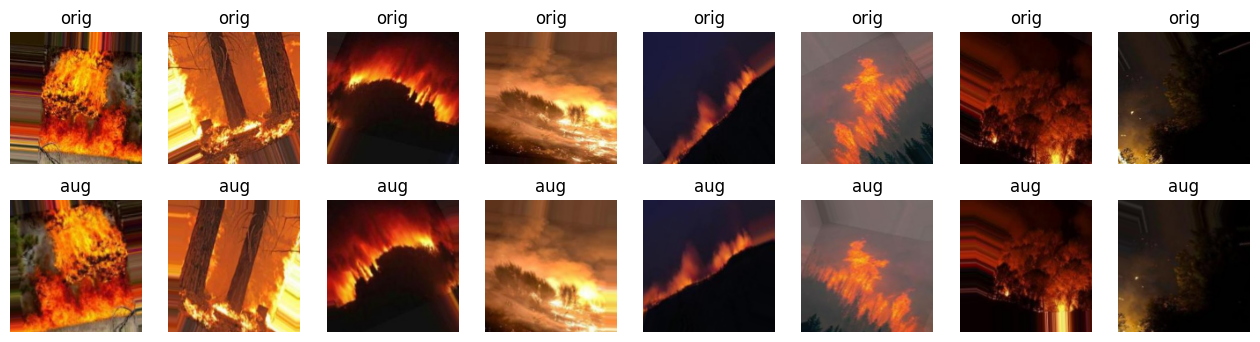

In [16]:
import matplotlib.pyplot as plt
batch_x, batch_y = next(train_aug.flow(X[:8], y[:8], batch_size=8, shuffle=False))
plt.figure(figsize=(16,4))
for i in range(8):
    plt.subplot(2,8,i+1);    plt.imshow(X[i]);        plt.axis('off'); plt.title('orig')
    plt.subplot(2,8,i+9);    plt.imshow(np.clip(batch_x[i],0,1)); plt.axis('off'); plt.title('aug')
plt.show()

In [17]:
from tensorflow.keras import layers, models

def build_firenet(input_shape=(150,150,3)):
    m = models.Sequential(name='FireNet_CNN')
    m.add(layers.Input(shape=input_shape))
    for f in [32, 64, 128, 256, 512]:
        m.add(layers.Conv2D(f, (3,3), activation='relu'))   # padding='valid' (default)
        m.add(layers.MaxPooling2D((2,2)))
        m.add(layers.BatchNormalization())
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(256, activation='relu'))
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(1, activation='sigmoid'))
    return m

model = build_firenet()
model.summary()


Model: "FireNet_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 74, 74, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,217 (10.50 MB)

 Trainable params: 2,751,233 (10.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [19]:
import os, glob, time, random, pickle
import numpy as np, cv2, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    jaccard_score, matthews_corrcoef, roc_auc_score, confusion_matrix, roc_curve)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(tf.config.list_physical_devices('GPU'))     # must list a GPU

# ---------- data ----------
BASE = '/content/drive/MyDrive/processed'
FIRE_CLASSES, NOFIRE_CLASSES = ['fire', 'smokefire'], ['nofire', 'smoke']
X, y, paths = [], [], []
for split in ['train', 'val', 'test']:
    for cls in FIRE_CLASSES + NOFIRE_CLASSES:
        label = 1 if cls in FIRE_CLASSES else 0
        for p in sorted(glob.glob(f'{BASE}/{split}/{cls}/*')):
            img = cv2.imread(p)
            if img is None: continue
            X.append(cv2.cvtColor(cv2.resize(img, (150,150)), cv2.COLOR_BGR2RGB)); y.append(label); paths.append(p)
assert len(X) > 0, "No images loaded - check BASE"
X = np.array(X, dtype='float32') / 255.0
y = np.array(y, dtype='int64')
print(X.shape, np.bincount(y))       # expect (4800,150,150,3) [2400 2400]

# ---------- model ----------
def build_firenet(input_shape=(150,150,3)):
    m = models.Sequential(name='FireNet_CNN')
    m.add(layers.Input(shape=input_shape))
    for f in [32, 64, 128, 256, 512]:
        m.add(layers.Conv2D(f, (3,3), activation='relu'))
        m.add(layers.MaxPooling2D((2,2)))
        m.add(layers.BatchNormalization())
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation='relu')); m.add(layers.Dropout(0.5))
    m.add(layers.Dense(256, activation='relu')); m.add(layers.Dropout(0.5))
    m.add(layers.Dense(1, activation='sigmoid'))
    return m

# ---------- augmentation + tf.data ----------
AUTOTUNE = tf.data.AUTOTUNE
aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'), layers.RandomRotation(20/360),
    layers.RandomTranslation(0.1, 0.1), layers.RandomZoom(0.15)], name='augmentation')

def make_ds(X_, y_, train=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X_, y_))
    if train: ds = ds.shuffle(len(X_), seed=SEED)
    ds = ds.batch(batch_size)
    if train: ds = ds.map(lambda a, b: (aug(a, training=True), b), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

# ---------- folds ----------
SAVE_DIR = '/content/drive/MyDrive/firenet_results'
os.makedirs(SAVE_DIR, exist_ok=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(X, y))
print([(len(a), len(b)) for a, b in folds])       # expect (3840, 960) x5

[]
(4800, 150, 150, 3) [2400 2400]
[(3840, 960), (3840, 960), (3840, 960), (3840, 960), (3840, 960)]


In [20]:
def run_fold(k, epochs=50, batch_size=32):
    out_path = f'{SAVE_DIR}/fold{k}.pkl'
    if os.path.exists(out_path):
        print(f'Fold {k} already done, skipping'); return
    tr, va = folds[k-1]
    tf.keras.backend.clear_session()

    model = build_firenet()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    t0 = time.time()
    h = model.fit(make_ds(X[tr], y[tr], True, batch_size),
                  validation_data=make_ds(X[va], y[va], False, batch_size),
                  epochs=epochs, verbose=2)
    train_time = time.time() - t0

    prob = model.predict(X[va], batch_size=64, verbose=0).ravel()
    model.save(f'{SAVE_DIR}/firenet_fold{k}.keras')
    with open(out_path, 'wb') as f:
        pickle.dump({'history': h.history, 'val_idx': va, 'y_true': y[va],
                     'y_prob': prob, 'train_time': train_time}, f)

    acc = ((prob > 0.5).astype(int) == y[va]).mean()
    print(f'Fold {k}: val acc = {acc:.4f} | train time = {train_time:.0f}s')

In [21]:
run_fold(1)

Fold 1 already done, skipping


In [22]:
meta = pd.read_csv('/content/drive/MyDrive/processed/metadata.csv')
print(meta.shape); print(meta.columns.tolist()); meta.head(10)

(4800, 4)
['split', 'label', 'image_path', 'source']


,split,label,image_path,source
0,train,fire,processed\train\fire\fire_train_1001.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
1,train,fire,processed\train\fire\fire_train_1002.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
2,train,fire,processed\train\fire\fire_train_1003.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
3,train,fire,processed\train\fire\fire_train_1004.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
4,train,fire,processed\train\fire\fire_train_1005.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
5,train,fire,processed\train\fire\fire_train_1006.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
6,train,fire,processed\train\fire\fire_train_1007.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
7,train,fire,processed\train\fire\fire_train_1008.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
8,train,fire,processed\train\fire\fire_train_1009.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...
9,train,fire,processed\train\fire\fire_train_1010.jpg,dataset\Forect Fire\Forest Fire_Dataset\train\...


In [23]:
meta = pd.read_csv('/content/drive/MyDrive/processed/metadata.csv')
meta['src_folder'] = meta['source'].str.replace('\\', '/', regex=False).str.split('/').str[:3].str.join('/')
print(pd.crosstab(meta['src_folder'], meta['label']))

for lab in ['fire','smokefire','smoke','nofire']:
    print(lab, meta[meta.label==lab]['source'].sample(3, random_state=1).tolist())

label                                    fire  nofire  smoke  smokefire
src_folder                                                             
dataset/Forect Fire/Forest Fire_Dataset  1200    1200   1200       1200
fire ['dataset\\Forect Fire\\Forest Fire_Dataset\\train\\fire\\fire_train_1637.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\train\\fire\\fire_train_1684.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\test\\fire\\fire_test_1034.jpg']
smokefire ['dataset\\Forect Fire\\Forest Fire_Dataset\\train\\smokefire\\smokefire_train_1637.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\train\\smokefire\\smokefire_train_1684.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\test\\smokefire\\smokefire_test_1034.jpg']
smoke ['dataset\\Forect Fire\\Forest Fire_Dataset\\train\\smoke\\smoke_train_1637.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\train\\smoke\\smoke_train_1684.jpg', 'dataset\\Forect Fire\\Forest Fire_Dataset\\test\\smoke\\smoke_test_1034.jpg']
nofire ['dataset\\F

In [24]:
import hashlib
groups = {}
for i in range(len(X)):
    groups.setdefault(hashlib.md5(X[i].tobytes()).hexdigest(), []).append(i)

dups = [v for v in groups.values() if len(v) > 1]
conflict = [v for v in dups if len(set(y[v])) > 1]
print("duplicate groups:", len(dups), "| images involved:", sum(len(v) for v in dups))
print("groups with conflicting labels:", len(conflict))

duplicate groups: 0 | images involved: 0
groups with conflicting labels: 0


In [25]:
import glob, pickle
R = [pickle.load(open(f,'rb')) for f in sorted(glob.glob(f'{SAVE_DIR}/fold*.pkl'))]
orig_cls = np.array([p.split('/')[-2] for p in paths])     # original 4-class label of each image

rows = []
for r in R:
    va, yp = r['val_idx'], (r['y_prob'] > 0.5).astype(int)
    for c in ['fire', 'smokefire', 'smoke', 'nofire']:
        m = orig_cls[va] == c
        rows.append((c, m.sum(), (yp[m] != r['y_true'][m]).sum()))
err = pd.DataFrame(rows, columns=['class','n','errors']).groupby('class').sum()
err['error_rate_%'] = (err.errors / err.n * 100).round(2)
display(err)

,n,errors,error_rate_%
class,,,
fire,1200,38,3.17
nofire,1200,41,3.42
smoke,1200,33,2.75
smokefire,1200,134,11.17


In [26]:
for k in [2, 3, 4, 5]:
    run_fold(k)

Fold 2 already done, skipping
Fold 3 already done, skipping
Fold 4 already done, skipping
Fold 5 already done, skipping


In [27]:
import glob, pickle
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    jaccard_score, matthews_corrcoef, roc_auc_score, confusion_matrix, roc_curve)

def load_results(prefix):
    """prefix='fold' for FireNet-CNN, 'VGG16_fold' etc. for baselines"""
    files = sorted(glob.glob(f'{SAVE_DIR}/{prefix}[0-9].pkl'))
    return [pickle.load(open(f, 'rb')) for f in files]

def fold_metrics(r):
    yt, pr = r['y_true'], r['y_prob']; yp = (pr > 0.5).astype(int)
    return dict(accuracy=accuracy_score(yt, yp), precision=precision_score(yt, yp),
                recall=recall_score(yt, yp), f1=f1_score(yt, yp),
                jaccard=jaccard_score(yt, yp), mcc=matthews_corrcoef(yt, yp),
                auc=roc_auc_score(yt, pr))

def metrics_table(R):
    df = pd.DataFrame([fold_metrics(r) for r in R], index=range(1, len(R)+1))
    df.index.name = 'fold'
    return df

R = load_results('fold')
print(len(R), 'folds loaded')
df = metrics_table(R)
df['train_acc'] = [r['history']['accuracy'][-1] for r in R]
df['val_acc_last5'] = [np.mean(r['history']['val_accuracy'][-5:]) for r in R]
df['train_loss'] = [r['history']['loss'][-1] for r in R]
df['val_loss'] = [r['history']['val_loss'][-1] for r in R]
display(df.round(4))
print('MEAN ± STD across folds')
display(pd.DataFrame({'mean': df.mean(), 'std': df.std()}).round(4))

5 folds loaded


,accuracy,precision,recall,f1,jaccard,mcc,auc,train_acc,val_acc_last5,train_loss,val_loss
fold,,,,,,,,,,,
1,0.9396,0.9587,0.9188,0.9383,0.8838,0.8799,0.9889,0.9661,0.9375,0.0810,0.1537
2,0.9573,0.9761,0.9375,0.9564,0.9165,0.9153,0.9942,0.9664,0.9579,0.0937,0.1028
3,0.9615,0.9723,0.9500,0.9610,0.9249,0.9232,0.9921,0.9667,0.9569,0.0894,0.1315
4,0.9479,0.9594,0.9354,0.9473,0.8998,0.8961,0.9917,0.9604,0.9463,0.0949,0.1200
5,0.9375,0.9730,0.9000,0.9351,0.8780,0.8775,0.9875,0.9651,0.9542,0.0889,0.2276


MEAN ± STD across folds


,mean,std
accuracy,0.9488,0.0106
precision,0.9679,0.0082
recall,0.9283,0.0194
f1,0.9476,0.0112
jaccard,0.9006,0.0202
mcc,0.8984,0.0205
auc,0.9909,0.0027
train_acc,0.9649,0.0026
val_acc_last5,0.9505,0.0086
train_loss,0.0896,0.0054


In [28]:
paper_A = {'accuracy':.9796,'precision':.9822,'recall':.9841,'f1':.9831,
           'jaccard':.9668,'mcc':.9645,'auc':.9980,
           'train_acc':.9930,'train_loss':.052,'val_loss':.071}
cmp = pd.DataFrame({'Paper (Dataset A)': pd.Series(paper_A),
                    'Yours (mean)': df.mean()}).dropna()
cmp['Difference'] = cmp['Yours (mean)'] - cmp['Paper (Dataset A)']
display(cmp.round(4))
cmp.round(4).to_csv(f'{SAVE_DIR}/comparison_firenet_vs_paper.csv')

,Paper (Dataset A),Yours (mean),Difference
accuracy,0.9796,0.9488,-0.0308
auc,0.9980,0.9909,-0.0071
f1,0.9831,0.9476,-0.0355
jaccard,0.9668,0.9006,-0.0662
mcc,0.9645,0.8984,-0.0661
precision,0.9822,0.9679,-0.0143
recall,0.9841,0.9283,-0.0558
train_acc,0.9930,0.9649,-0.0281
train_loss,0.0520,0.0896,0.0376
val_loss,0.0710,0.1471,0.0761


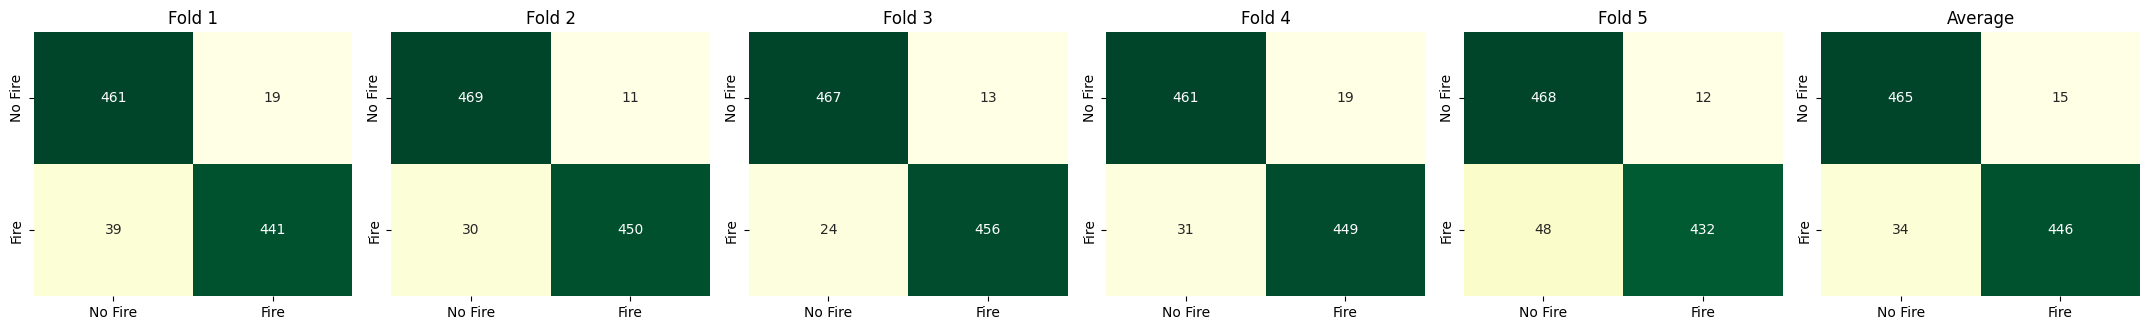

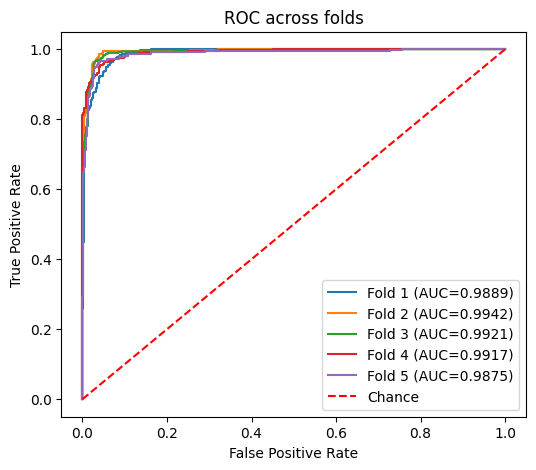

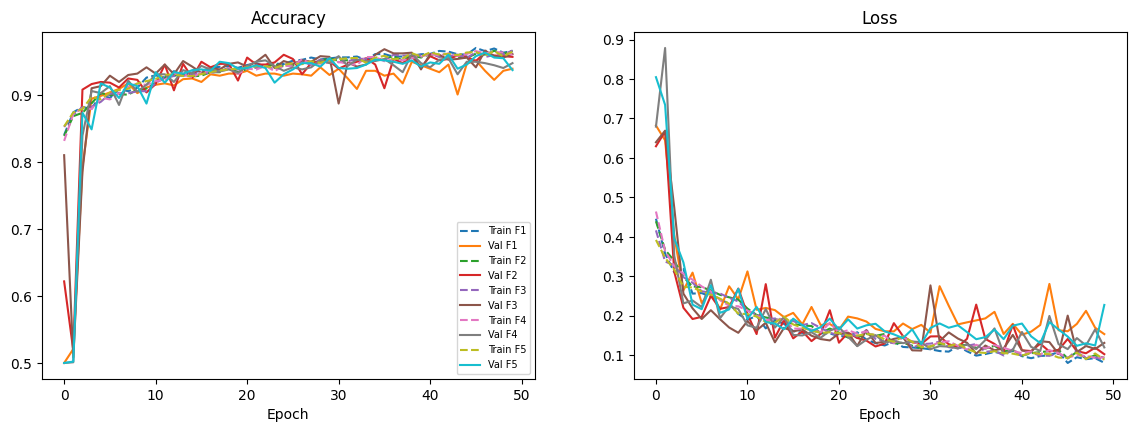

In [29]:
# confusion matrices per fold + average
n = len(R); fig, ax = plt.subplots(1, n+1, figsize=(3.6*(n+1), 3.4))
cms = [confusion_matrix(r['y_true'], (r['y_prob']>0.5).astype(int)) for r in R]
ax = np.atleast_1d(ax)
for i, cm in enumerate(cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', cbar=False, ax=ax[i],
                xticklabels=['No Fire','Fire'], yticklabels=['No Fire','Fire']); ax[i].set_title(f'Fold {i+1}')
sns.heatmap(np.mean(cms, 0), annot=True, fmt='.0f', cmap='YlGn', cbar=False, ax=ax[-1],
            xticklabels=['No Fire','Fire'], yticklabels=['No Fire','Fire']); ax[-1].set_title('Average')
plt.tight_layout(); plt.show()

# ROC
plt.figure(figsize=(6,5))
for k, r in enumerate(R, 1):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'])
    plt.plot(fpr, tpr, label=f"Fold {k} (AUC={roc_auc_score(r['y_true'], r['y_prob']):.4f})")
plt.plot([0,1],[0,1],'r--', label='Chance'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC across folds'); plt.legend(); plt.show()

# accuracy + loss curves, all folds
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
for k, r in enumerate(R, 1):
    h = r['history']
    ax[0].plot(h['accuracy'], '--', label=f'Train F{k}'); ax[0].plot(h['val_accuracy'], label=f'Val F{k}')
    ax[1].plot(h['loss'], '--', label=f'Train F{k}');     ax[1].plot(h['val_loss'], label=f'Val F{k}')
ax[0].set_title('Accuracy'); ax[1].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[1].set_xlabel('Epoch')
ax[0].legend(fontsize=7); plt.show()

In [30]:
orig_cls = np.array([p.replace('\\','/').split('/')[-2] for p in paths])
rows = []
for r in R:
    va, yp = r['val_idx'], (r['y_prob'] > 0.5).astype(int)
    for c in ['fire','smokefire','smoke','nofire']:
        m = orig_cls[va] == c
        rows.append((c, m.sum(), (yp[m] != r['y_true'][m]).sum()))
err = pd.DataFrame(rows, columns=['class','n','errors']).groupby('class').sum()
err['error_rate_%'] = (err.errors / err.n * 100).round(2)
display(err)

,n,errors,error_rate_%
class,,,
fire,1200,38,3.17
nofire,1200,41,3.42
smoke,1200,33,2.75
smokefire,1200,134,11.17


In [31]:
from tensorflow.keras.applications import VGG16, VGG19, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as pre_vgg16
from tensorflow.keras.applications.vgg19 import preprocess_input as pre_vgg19

BASELINES = {
    'VGG16':       (VGG16,       lambda a: pre_vgg16(a * 255.0)),
    'VGG19':       (VGG19,       lambda a: pre_vgg19(a * 255.0)),
    'InceptionV3': (InceptionV3, lambda a: a * 2.0 - 1.0),
}

def build_baseline(name):
    base = BASELINES[name][0](weights='imagenet', include_top=False, input_shape=(150,150,3))
    return models.Sequential([base, layers.Flatten(),
        layers.Dense(512, activation='relu'), layers.Dropout(0.5),
        layers.Dense(256, activation='relu'), layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')], name=name)

def make_ds_pre(X_, y_, pre, train=True, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((X_, y_))
    if train: ds = ds.shuffle(len(X_), seed=SEED)
    ds = ds.batch(batch_size)
    if train: ds = ds.map(lambda a, b: (aug(a, training=True), b), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda a, b: (pre(a), b), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

In [32]:
def run_baseline(name, k, epochs=15, lr=1e-5, batch_size=32):
    out_path = f'{SAVE_DIR}/{name}_fold{k}.pkl'
    if os.path.exists(out_path):
        print(f'{name} fold {k} already done, skipping'); return
    tr, va = folds[k-1]; pre = BASELINES[name][1]
    tf.keras.backend.clear_session()
    model = build_baseline(name)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    t0 = time.time()
    h = model.fit(make_ds_pre(X[tr], y[tr], pre, True, batch_size),
                  validation_data=make_ds_pre(X[va], y[va], pre, False, batch_size),
                  epochs=epochs, verbose=2)
    train_time = time.time() - t0
    prob = model.predict(make_ds_pre(X[va], y[va], pre, False, 64), verbose=0).ravel()
    with open(out_path, 'wb') as f:
        pickle.dump({'history': h.history, 'val_idx': va, 'y_true': y[va], 'y_prob': prob,
                     'train_time': train_time, 'epochs': epochs}, f)
    print(f'{name} fold {k}: val acc = {((prob>0.5).astype(int)==y[va]).mean():.4f} | {train_time:.0f}s')

In [33]:
# Option 1 (recommended first): fold 1 only, all three models (~40 min)
for name in BASELINES:
    run_baseline(name, 1)

# Option 2 (full, ~3 hrs): all folds; add later if time allows
# for name in BASELINES:
#     for k in [2,3,4,5]:
#         run_baseline(name, k)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
120/120 - 3982s - 33s/step - accuracy: 0.5409 - loss: 1.2776 - val_accuracy: 0.7323 - val_loss: 0.5785
Epoch 2/15
120/120 - 3935s - 33s/step - accuracy: 0.6807 - loss: 0.5769 - val_accuracy: 0.8417 - val_loss: 0.3885
Epoch 3/15


KeyboardInterrupt: 

In [39]:
paper_T6 = pd.DataFrame({   # Dataset A values from the paper
    'FireNet-CNN': [97.96, 98.22, 98.41, 98.31, 96.68, 96.45],
    'VGG16':       [95.30, 95.51, 95.79, 95.65, 91.67, 90.89],
    'VGG19':       [95.24, 95.80, 95.64, 95.72, 91.81, 91.04],
    'InceptionV3': [97.53, 98.13, 97.58, 97.86, 95.80, 95.52]},
    index=['accuracy','precision','recall','f1','jaccard','mcc'])

def mean_metrics(prefix, only_folds=None):
    R_ = load_results(prefix)
    if only_folds: R_ = [R_[i-1] for i in only_folds if i <= len(R_)]
    return metrics_table(R_).mean()[['accuracy','precision','recall','f1','jaccard','mcc']] * 100

FOLDS_USED = [1]        # set to None if you ran all 5 folds for everything
yours = pd.DataFrame({
    'FireNet-CNN': mean_metrics('fold', FOLDS_USED),
    'VGG16':       mean_metrics('VGG16_fold', FOLDS_USED),
    'VGG19':       mean_metrics('VGG19_fold', FOLDS_USED),
    'InceptionV3': mean_metrics('InceptionV3_fold', FOLDS_USED)})
print('PAPER (Dataset A)'); display(paper_T6.round(2))
print('YOURS');             display(yours.round(2))
print('DIFFERENCE (yours - paper)'); display((yours - paper_T6).round(2))
yours.round(2).to_csv(f'{SAVE_DIR}/table6_yours.csv')

KeyError: "None of [Index(['accuracy', 'precision', 'recall', 'f1', 'jaccard', 'mcc'], dtype='object')] are in the [index]"